# ASTROVITAL AI : VITALX CORE V1
## NOTEBOOK 03: FEATURE ENGINEERING

**Developer:** Gouragopal Mohapatra  
**GitHub:** GOURGOPAL618  
**Date:** March 20, 2026  
**Slogan:** *"Because Every Heartbeat in Space Matters."*

---

## ⚠️ COPYRIGHT NOTICE
© 2026 Gouragopal Mohapatra — All Rights Reserved  
ASTROVITAL AI — VITALX CORE V1 — Independent Research  
Not affiliated with any institution.  
Unauthorized use, reproduction or distribution is strictly  
prohibited under Indian Copyright Act, 1957 &  
Berne Convention for Protection of Literary & Artistic Works.

### PURPOSE:
Create a new meaningful features from existing physioogical
parameters to to enhance the model preformance for all 3 innovation.
input: astrovital_clean_v1.csv
output:astrovital_features_v1.csv


In [33]:
# ============================================
# ASTROVITAL AI — VITALX CORE V1
# Notebook 03 — Feature Engineering
# Developer: Gouragopal Mohapatra
# GitHub: GOURGOPAL618
# Date: March 20, 2026
# © 2026 Gouragopal Mohapatra — All Rights Reserved
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('dark_background')
sns.set_palette('coolwarm')

# Load clean dataset
df = pd.read_csv('../DATA_VAULT/MISSION_READY_DATA/astrovital_clean_v1.csv')

print("=" * 57)
print("  ASTROVITAL AI : VITALX CORE V1")
print("  Notebook 03: Faeture Engineering")
print("  Because Every Heartbeat in Space Matters.")
print("=" * 57)
print(f"✅ Dataset Loaded successfully!")
print(f"✅ Shape: {df.shape}")
print(f"✅ Columns: {list(df.columns)}")
print(f"\n📊 First 5 Records:")
print(df.head())

  ASTROVITAL AI : VITALX CORE V1
  Notebook 03: Faeture Engineering
  Because Every Heartbeat in Space Matters.
✅ Dataset Loaded successfully!
✅ Shape: (1000, 13)
✅ Columns: ['Astronaut_ID', 'Mission_Type', 'Mission_Duration_Days', 'Heart_rate_bpm', 'Systolic_BP_mmHg', 'Diastolic_BP_mmHg', 'Sleep_Hours', 'Oxygen_Saturation', 'Muscle_Loss_Percent', 'Bone_Density_Loss', 'Radiation_mSv', 'Immune_Score', 'Health_Status']

📊 First 5 Records:
  Astronaut_ID Mission_Type  Mission_Duration_Days  Heart_rate_bpm  \
0   ASTRO_0001          LEO                     76           88.29   
1   ASTRO_0002         Mars                    667           82.87   
2   ASTRO_0003   Deep_Space                    197           57.24   
3   ASTRO_0004          LEO                    109           97.73   
4   ASTRO_0005          LEO                    112          101.68   

   Systolic_BP_mmHg  Diastolic_BP_mmHg  Sleep_Hours  Oxygen_Saturation  \
0            103.10              63.80         5.64             

## Feature Engineering Plan

### Why Feature Engineering?
> Raw Parameters alone may not capture the full
> Physiological story. New engineered features help
> Model detect complex health parameters that single
> Parameters can not reveal alone.

### New Features to Create:
| Feature | Formula | Purpose |
|---|---|---|
| **Pulse_Pressure** | Systolic - Diastolic BP | Cardiovascular stress indicator |
| **Cardio_Risk_Index** | HR x Systolic_BP / 1000 | Combined cardiac risk score |
| **Sleep_Deficit** | 7.0 - Sleep_Hours | How much sleep is missing |
| **Musculo_Risk** | Muscle_Loss + Bone_Density_Loss | Combined musculoskeletal risk |
| **Radiation_Risk** | Radiation / Mission_Duration | Radiation per day exposure |
| **Overall_Risk_Score** | Weighted sum of all risks | Master health risk indicator |

### Input:
> DATA_VAULT/MISSION_READY_DATA/astrovital_clean_v1.csv

### Output:
> DATA_VAULT/MISSION_READY_DATA/astrovital_features_v1.csv

In [34]:
# ============================================
# Feature Engineering — New Features Creation
# ============================================

df_feat = df.copy()

# Feature 1 - Pulse Pressure
df_feat['Pulse_Pressure'] = (
    df_feat['Systolic_BP_mmHg'] - df_feat['Diastolic_BP_mmHg']
)

# Feature 2 - Cardio Risk Index
df_feat['Cardio_Risk_Index'] = (
    df_feat['Heart_rate_bpm'] * df_feat['Systolic_BP_mmHg'] / 1000
).round(4)

# Feature 3 - Sleep Deficit
df_feat['Sleep_Deficit'] = (
    7.0 - df_feat['Sleep_Hours']
).round(2)

# Feature 4 - Musculoskeletal Risk
df_feat['Musculo_Risk'] = (
    df_feat['Muscle_Loss_Percent'] + 
    df_feat['Bone_Density_Loss'] * 10
).round(6)

# Feature 5 - Radiation Risk Per Day
df_feat['Radiation_Risk_Per_Day'] = (
    df_feat['Radiation_mSv'] /
    df_feat['Mission_Duration_Days']
).round(6)

# Feature 6 - Overall Risk Score
df_feat['Overall_Risk_Score'] = (
    (df_feat['Cardio_Risk_Index'] / df_feat['Cardio_Risk_Index'].max()) * 0.25 +
    (df_feat['Sleep_Deficit'] / df_feat['Sleep_Deficit'].max()) * 0.20 + 
    (df_feat['Musculo_Risk'] / df_feat['Musculo_Risk'].max()) * 0.20 +
    (df_feat['Radiation_mSv'] / df_feat['Radiation_mSv'].max()) * 0.20 +
    (1 - df_feat['Immune_Score'] / 100) * 0.15
).round(4)

print("=" * 57)
print("  New Features Created!")
print("=" * 57)

new_features = [
    'Pulse_Pressure', 'Cardio_Risk_Index',
    'Sleep_Deficit', 'Musculo_Risk',
    'Radiation_Risk_Per_Day', 'Overall_Risk_Score'
]

for feat in new_features:
    print(f"✅ {feat} - Created")

print(f"\nTotal Columns Now: {df_feat.shape[1]}")
print(f"\n📊 New Features Preview:")
print(df_feat[new_features].head())

  New Features Created!
✅ Pulse_Pressure - Created
✅ Cardio_Risk_Index - Created
✅ Sleep_Deficit - Created
✅ Musculo_Risk - Created
✅ Radiation_Risk_Per_Day - Created
✅ Overall_Risk_Score - Created

Total Columns Now: 19

📊 New Features Preview:
   Pulse_Pressure  Cardio_Risk_Index  Sleep_Deficit  Musculo_Risk  \
0           39.30             9.1027           1.36        11.570   
1           50.36             8.7594           1.68        23.537   
2           23.80             5.3828           1.14         8.026   
3           39.51            10.3428           0.53        17.825   
4           24.82             9.4867           2.40        14.389   

   Radiation_Risk_Per_Day  Overall_Risk_Score  
0                0.299474              0.3816  
1                0.094873              0.5851  
2                0.238832              0.3242  
3                0.302202              0.3664  
4                0.138036              0.4318  


### Engineered Features - Scientific Justification

### Feature 1 - Pulse Pressure
> **Formula:** Systolic BP - Diastolic BP  
> **Normal Range:** 40-60 mmHg  
> **Space Relevance:** Elevated pulse pressure indicates
> cardiovascular stress — common in microgravity.  
> Source: Vernice et al. 2020

### Feature 2 -  Cardio Risk Index
> **Formula:** Heart Rate x Systolic BP / 1000  
> **Purpose:** Combined cardiac workload indicator  
> **Space Relevance:** Captures dual cardiovascular
> stress — both rate and pressure simultaneously.

### Feature 3 - Sleep Deficit
> **Formula:** 7.0 - Sleep Hours  
> **Purpose:** Quantifies sleep deprivation severity  
> **Space Relevance:** ISS astronauts average 5.4 hours —
> deficit directly impacts cognitive performance.   
> Source: Albornoz-Miranda et al. 2023

### Feature 4 - Musculoskeletal Risk
> **Formula:** Muscle Loss + Bone Density Loss x 10  
> **Purpose:** Combined musculoskeletal degradation score  
> **Space Relevance:** Both systems degrade simultaneously
> in microgravity — combined score more predictive.  
> Source: Lee et al. 2020, Khan et al. 2024

### Feature 5 - Radiation Risk Per Day
> **Formula:** Radiation mSv / Mission Duration Days  
> **Purpose:** Daily radiation exposure rate  
> **Space Relevance:** Mars missions — 0.5-1.0 Sv total —
> daily rate matters for long-term risk assessment.

### Feature 6 - Overall Risk Score
> **Formula:** Weighted combination of all risk factors  
> **Weights:** Cardio 25% · Sleep 20% · Musculo 20% ·  
> Radiation 20% · Immune 15%  
> **Purpose:** Master health risk indicator for CDSS

In [35]:
# ============================================
# Correlation Matrix Analysis
# ============================================

numerical_cols = [
    'Heart_rate_bpm', 'Systolic_BP_mmHg', 'Diastolic_BP_mmHg',
    'Sleep_Hours', 'Oxygen_Saturation', 'Muscle_Loss_Percent',
    'Bone_Density_Loss', 'Radiation_mSv', 'Immune_Score',
    'Pulse_Pressure', 'Cardio_Risk_Index', 'Sleep_Deficit',
    'Musculo_Risk', 'Overall_Risk_Score'
]

corr_matrix = df_feat[numerical_cols].corr()

print("=" * 57)
print("  Correlation Matrix - Top Correlations")
print("=" * 57)

# Top Correlationwith Overall Risk Score
risk_corr = corr_matrix['Overall_Risk_Score'].sort_values(
    ascending = False
)

print("\nTop Correlation With Overall Risk Score:")
print(risk_corr.round(4))

  Correlation Matrix - Top Correlations

Top Correlation With Overall Risk Score:
Overall_Risk_Score     1.0000
Radiation_mSv          0.5796
Sleep_Deficit          0.4846
Cardio_Risk_Index      0.4301
Musculo_Risk           0.4224
Heart_rate_bpm         0.3181
Bone_Density_Loss      0.3176
Systolic_BP_mmHg       0.2960
Muscle_Loss_Percent    0.2750
Pulse_Pressure         0.2362
Diastolic_BP_mmHg      0.0169
Oxygen_Saturation      0.0024
Immune_Score          -0.2861
Sleep_Hours           -0.4846
Name: Overall_Risk_Score, dtype: float64


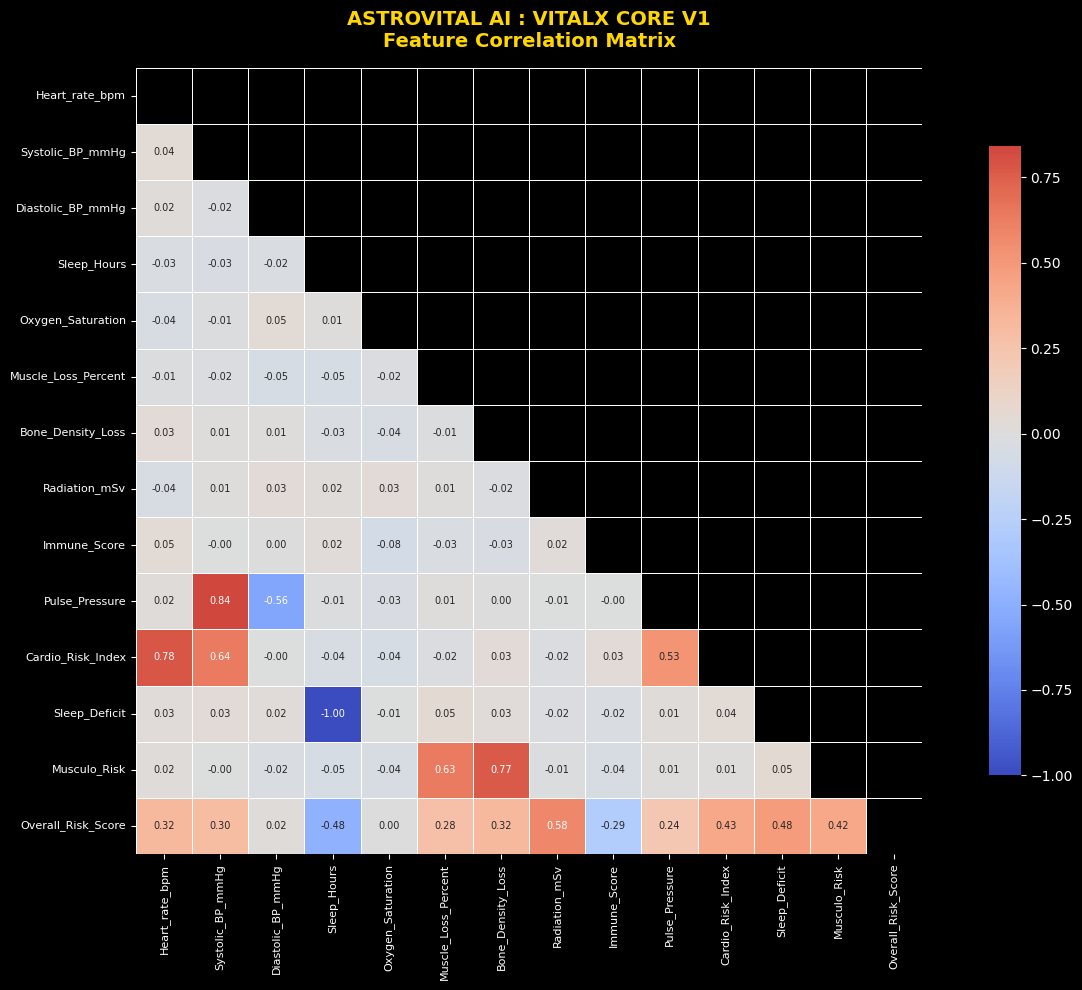

✅ Correlation heatmap complete!
✅ Key Insight: Check Overall Risk score correlation!


In [36]:
# ============================================
# Correlation Heatmap — Visualization
# ============================================

fig, ax = plt.subplots(figsize = (14, 10))

mask = np.zeros_like(corr_matrix, dtype = bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask = mask,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0,
    square = True,
    linewidths = 0.5,
    cbar_kws = {"shrink": 0.8},
    annot_kws = {"size": 7},
    ax = ax
)

ax.set_title(
    'ASTROVITAL AI : VITALX CORE V1\n'
    'Feature Correlation Matrix',
    color = 'gold', fontsize = 14, fontweight = 'bold', pad = 15
)
ax.tick_params(colors = 'white', labelsize = 8)

plt.tight_layout()
plt.show()

print("✅ Correlation heatmap complete!")
print("✅ Key Insight: Check Overall Risk score correlation!")

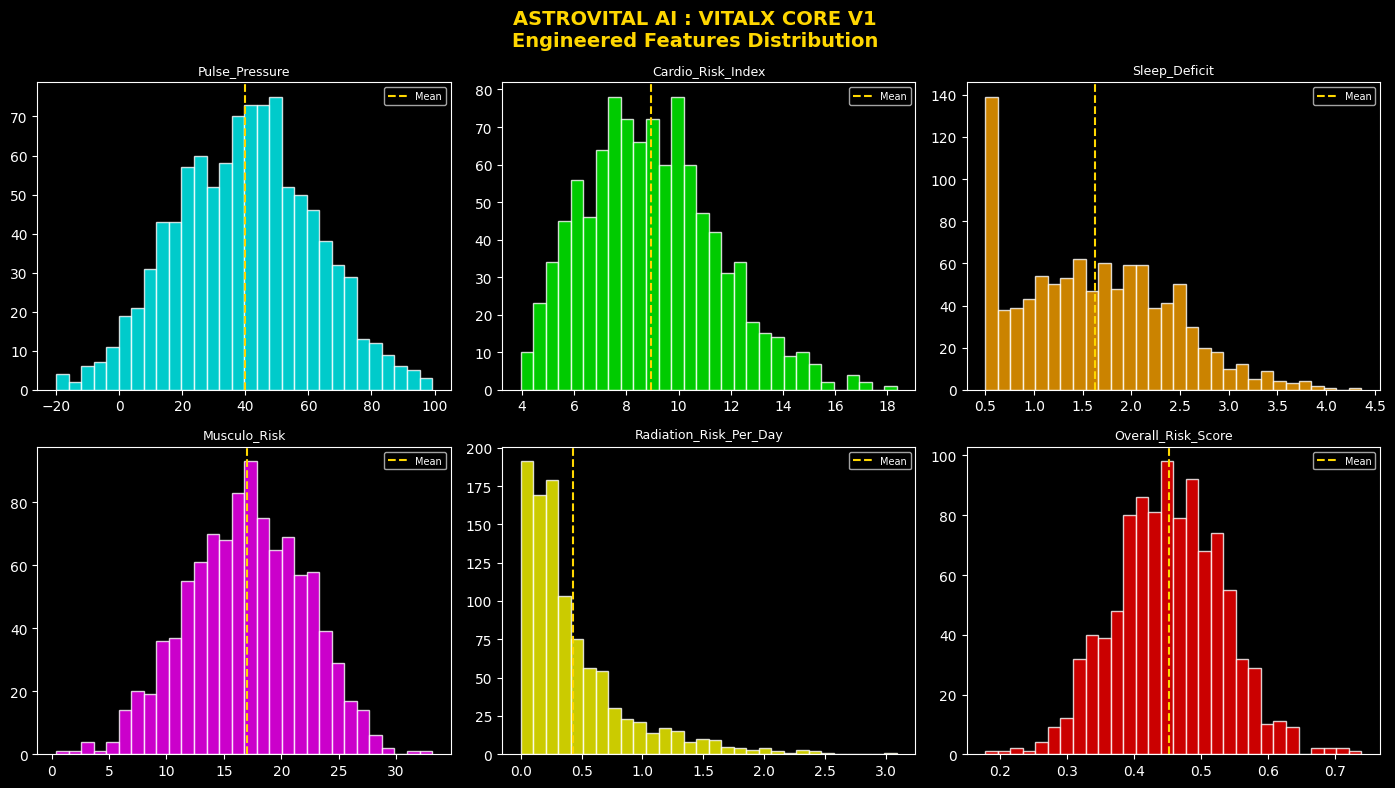

✅ Feature Distribution Visualization Complete!


In [37]:
# ============================================
# Engineered Features Distribution
# ============================================

new_features = [
    'Pulse_Pressure', 'Cardio_Risk_Index',
    'Sleep_Deficit', 'Musculo_Risk',
    'Radiation_Risk_Per_Day', 'Overall_Risk_Score'
]

fig, axes = plt.subplots(2, 3, figsize = (14, 8))
fig.suptitle(
    'ASTROVITAL AI : VITALX CORE V1\n'
    'Engineered Features Distribution',
    color = 'gold', fontsize = 14, fontweight = 'bold'
)

colors = ['cyan', 'lime', 'orange',
          'magenta', 'yellow', 'red']

for idx, (feat, color) in enumerate(zip(new_features, colors)):
    row, col = divmod(idx, 3)
    axes[row, col].hist(
        df_feat[feat], bins = 30,
        color = color, alpha = 0.8,
        edgecolor = 'white'
    )
    
    axes[row, col].set_title(feat, color = 'white', fontsize = 9)
    axes[row, col].tick_params(color = 'white')
    axes[row, col].axvline(
        df_feat[feat].mean(),
        color = 'gold', linestyle = '--',
        linewidth = 1.5, label = 'Mean'
    )
    axes[row, col].legend(fontsize = 7)

plt.tight_layout()
plt.show()
print("✅ Feature Distribution Visualization Complete!")

  Feature Importance preview
            Feature  Importance
  Bone_Density_Loss    0.163603
      Radiation_mSv    0.154300
       Musculo_Risk    0.111476
  Oxygen_Saturation    0.108948
   Systolic_BP_mmHg    0.090476
Muscle_Loss_Percent    0.066305
       Immune_Score    0.063876
 Overall_Risk_Score    0.057286
      Sleep_Deficit    0.038173
        Sleep_Hours    0.035406
  Cardio_Risk_Index    0.033453
     Heart_rate_bpm    0.032043
     Pulse_Pressure    0.028055
  Diastolic_BP_mmHg    0.016598


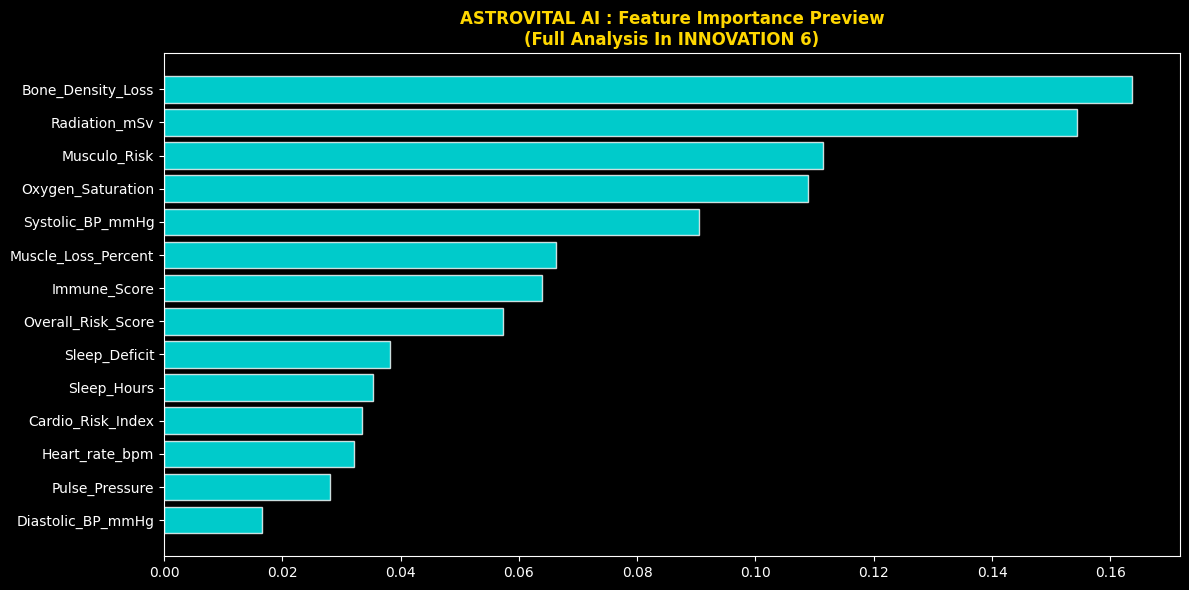

✅ Features Importance Preview Complete!
✅ Full Biomarker Discovery in Notebook 6!


In [38]:
# ============================================
# Feature Importance Preview
# Using Random Forest — Quick Check
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode Labels
le = LabelEncoder()
df_feat['Health_Status_Encoded'] = le.fit_transform(
    df_feat['Health_Status']
)

# Features for quick important check
feature_cols = [
    'Heart_rate_bpm', 'Systolic_BP_mmHg', 'Diastolic_BP_mmHg',
    'Sleep_Hours', 'Oxygen_Saturation', 'Muscle_Loss_Percent',
    'Bone_Density_Loss', 'Radiation_mSv', 'Immune_Score',
    'Pulse_Pressure', 'Cardio_Risk_Index', 'Sleep_Deficit',
    'Musculo_Risk','Overall_Risk_Score'
]

X = df_feat[feature_cols]
y = df_feat['Health_Status_Encoded']

# Quick RF For feature Importance Review
rf_preview = RandomForestClassifier(
    n_estimators = 50,
    random_state = 42
)
rf_preview.fit(X, y)

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_preview.feature_importances_
}).sort_values('Importance', ascending = False)

print("=" * 57)
print("  Feature Importance preview")
print("=" * 57)

print(importance_df.to_string(index = False))

# Graph 
fig, ax = plt.subplots(figsize = (12, 6))
bars = ax.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color = 'cyan', alpha = 0.8,
    edgecolor = 'white'
)

ax.tick_params(color = 'white')
ax.set_title(
    'ASTROVITAL AI : Feature Importance Preview\n'
    '(Full Analysis In INNOVATION 6)',
    color = 'gold', fontsize = 12, fontweight = 'bold'
)

ax.tick_params(colors = 'white')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("✅ Features Importance Preview Complete!")
print("✅ Full Biomarker Discovery in Notebook 6!")

In [39]:
# ============================================
# Final Dataset — Complete Check
# ============================================

print("=" * 57)
print("  Final Dataset - Complete Summary")
print("=" * 57)

print(f"✅ Total Records:  {df_feat.shape[0]}")
print(f"✅ Total Columns:  {df_feat.shape[1]}")
print(f"\n📊 All Columns:")
for i, col in enumerate (df_feat.columns, 1):
    print(f"  {i:02d}. {col}")

print(f"\n📊 Label Distribution:")
label_counts = df_feat['Health_Status'].value_counts()
print(f"   🟢 GREEN:  {label_counts.get('GREEN', 0)}")
print(f"   🟡 YELLOW:  {label_counts.get('YELLOW', 0)}")
print(f"   🔴 RED:    {label_counts.get('RED', 0)}")

print(f"\n📊 Missing Values: {df_feat.isnull().sum().sum()}")
print(f"\n📊 Statistical Summary:")
print(df_feat.describe().round(2))
print("\n✅ Dataset Ready For Innovation notebooks!")

  Final Dataset - Complete Summary
✅ Total Records:  1000
✅ Total Columns:  20

📊 All Columns:
  01. Astronaut_ID
  02. Mission_Type
  03. Mission_Duration_Days
  04. Heart_rate_bpm
  05. Systolic_BP_mmHg
  06. Diastolic_BP_mmHg
  07. Sleep_Hours
  08. Oxygen_Saturation
  09. Muscle_Loss_Percent
  10. Bone_Density_Loss
  11. Radiation_mSv
  12. Immune_Score
  13. Health_Status
  14. Pulse_Pressure
  15. Cardio_Risk_Index
  16. Sleep_Deficit
  17. Musculo_Risk
  18. Radiation_Risk_Per_Day
  19. Overall_Risk_Score
  20. Health_Status_Encoded

📊 Label Distribution:
   🟢 GREEN:  419
   🟡 YELLOW:  544
   🔴 RED:    37

📊 Missing Values: 0

📊 Statistical Summary:
       Mission_Duration_Days  Heart_rate_bpm  Systolic_BP_mmHg  \
count                1000.00         1000.00           1000.00   
mean                  225.48           85.28            104.88   
std                   204.83           18.31             18.11   
min                    30.00           55.00             70.00   
25%  

In [40]:
# ============================================
# Save Final Featured Dataset
# ============================================

save_path = "../DATA_VAULT/MISSION_READY_DATA/astrovital_features.v1.csv"
df_feat.to_csv(save_path, index = False)

print("=" * 57)
print("  Features Dataset Saved!")
print("=" * 57)

print(f"✅ File: astrovital_features_v1.csv")
print(f"✅ Location: DATA_VAULT/MISSION_READY_DATA/")
print(f"✅ Shape: {df_feat.shape}")
print(f"✅ Original Features: 12")
print(f"✅ Engineered Features: 6")
print(f"✅ Total Features: {df_feat.shape[1]}")
print(f"\n🚀 Ready For INNOVATION 3 - SENSOR CORRECTION!")
print(f"📁 Next: NOTEBOOK 04 - INNOVATION 3 PART 1")

  Features Dataset Saved!
✅ File: astrovital_features_v1.csv
✅ Location: DATA_VAULT/MISSION_READY_DATA/
✅ Shape: (1000, 20)
✅ Original Features: 12
✅ Engineered Features: 6
✅ Total Features: 20

🚀 Ready For INNOVATION 3 - SENSOR CORRECTION!
📁 Next: NOTEBOOK 04 - INNOVATION 3 PART 1


## NOTEBOOK 03 - COMPLETE  ✅

### What was accomplished:
- ✅ Clean dataset loaded from MISSION_READY_DATA
- ✅ 6 new features engineered - scientifically justified
- ✅ Correlation Matrix Computed
- ✅ Feature Importance preview - Random Forest
- ✅ Final Dataset Saved - astrovital_features_v1.csv

### Engineered Features Summary:
| Feature | Purpose |
|---|---|
| Pulse_Pressure | Cardiovascular stress |
| Cardio_Risk_Index | Combined cardiac risk |
| Sleep_Deficit | Sleep deprivation severity |
| Musculo_Risk | Musculoskeletal degradation |
| Radiation_Risk_Per_Day | Daily radiation exposure |
| Overall_Risk_Score | Master health risk indicator |

### Graphs Completed:
- ✅ Graph 1 - Correlation Heatmap
- ✅ Graph 2 - Feature Distribution
- ✅ Graph 3 - Feature Imporatnce Preview

### Next - Notebook 04:
> Innovation 3 - Sensor Noise Correlation
> Multiverse Regression + Random Forest
> Noisy data -> Clean signal

---
*ASTROVITAL AI — VITALX CORE V1*  
*"Because Every Heartbeat in Space Matters."*  
*© 2026 Gouragopal Mohapatra — All Rights Reserved*